<a href="https://colab.research.google.com/github/divyanavghare64-jpg/Data-Analytics-Lab/blob/main/Session_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Q1: Understanding & Dtaset Creation

from sklearn.datasets import make_blobs, load_iris
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.70, random_state=42)

df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
print(df.head(10))
print(df.shape)

   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846
(500, 2)


In [14]:
# Q2: Data Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled[:5])


[[-0.88847363  0.62990684]
 [-1.02890768 -1.56287499]
 [ 1.83106858 -0.23511276]
 [ 0.11655663  0.81467072]
 [-0.5065627  -1.60237008]]


In [15]:
# Q3: Basic K-Means clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df.head(10))

   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


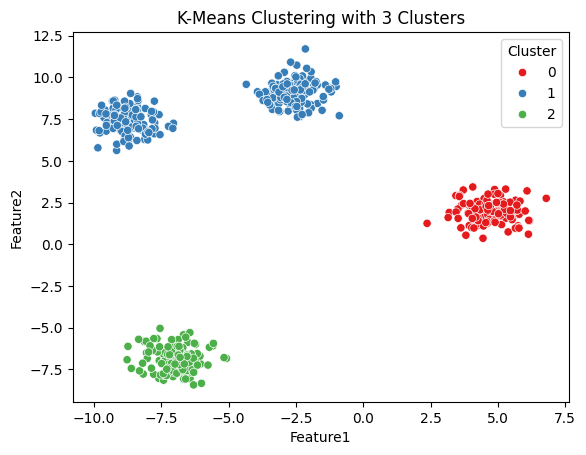

In [5]:
# Q4: Visulalizing Clusters
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Cluster', palette='Set1')
plt.title('K-Means Clustering with 3 Clusters')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

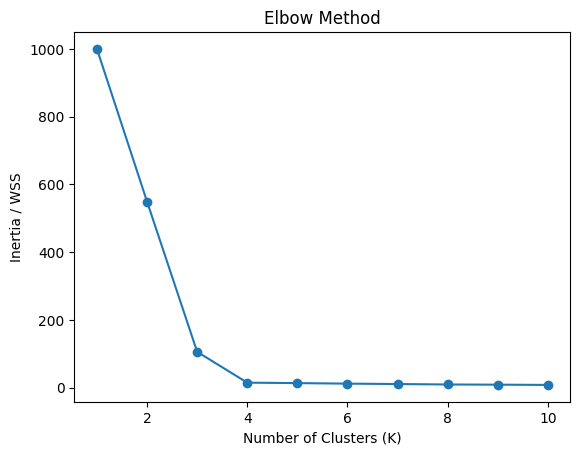

In [6]:
# Q5: Elbow Method finding Optional K
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia / WSS')
plt.show()

# Optimal K value looks to be 4 from the elbow graph

In [7]:
# Q6: final K-Means model
final_model = KMeans(n_clusters=4, random_state=42)
df['Final_Cluster'] = final_model.fit_predict(X_scaled)
print(df['Final_Cluster'].value_counts())

Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


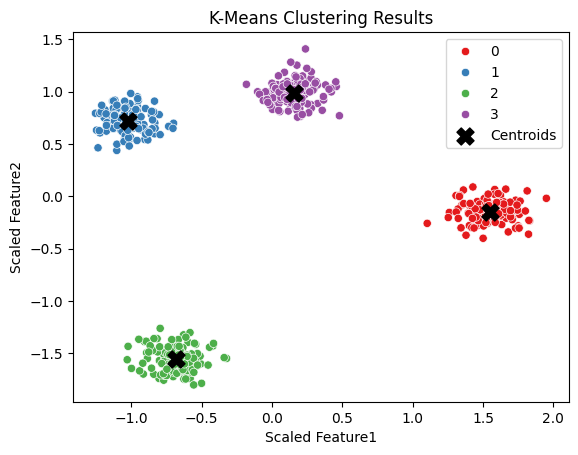

In [10]:
# Q7:  Visualizing final clusters
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['Final_Cluster'], palette='Set1')
centroids = final_model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=150, c='black', marker='X', label='Centroids')
plt.title('K-Means Clustering Results')
plt.xlabel('Scaled Feature1')
plt.ylabel('Scaled Feature2')
plt.legend()
plt.show()

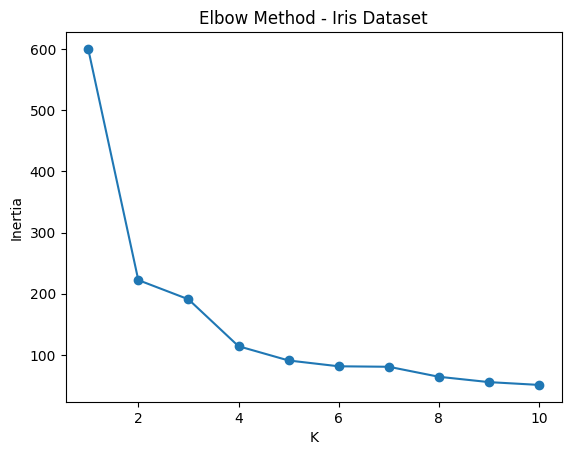

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [11]:
# Q8 & Q9: Real Dataset (Iris Dataset)
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Select numerical features & scale
iris_scaled = scaler.fit_transform(iris_df)

# Elbow method on Iris
iris_wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(iris_scaled)
    iris_wcss.append(km.inertia_)

plt.plot(range(1, 11), iris_wcss, marker='o')
plt.title('Elbow Method - Iris Dataset')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

# Train final Iris model (Optimal K=3)
iris_model = KMeans(n_clusters=3, random_state=42)
iris_df['Cluster'] = iris_model.fit_predict(iris_scaled)
print(iris_df['Cluster'].value_counts())

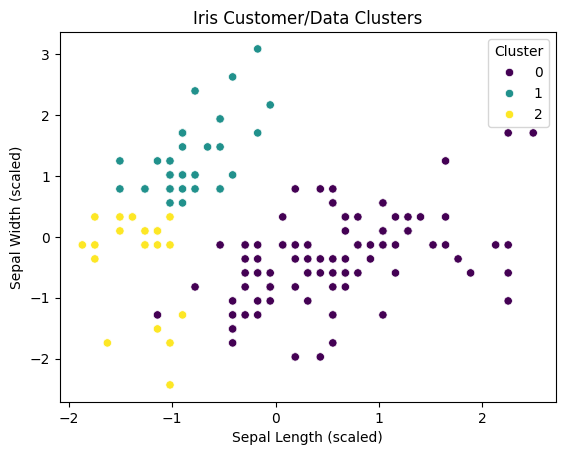

In [12]:
# Q10: Mini Project - Complete Clustering Pipeline
# 1. Load data
data = load_iris()
df_project = pd.DataFrame(data.data, columns=data.feature_names)

# 2. Scale features
scaled_data = StandardScaler().fit_transform(df_project)

# 3. Elbow method
project_wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    project_wcss.append(km.inertia_)

# 4. Train model with K=3
model = KMeans(n_clusters=3, random_state=42)
df_project['Cluster'] = model.fit_predict(scaled_data)

# 5. Visualize
sns.scatterplot(x=scaled_data[:, 0], y=scaled_data[:, 1], hue=df_project['Cluster'], palette='viridis')
plt.title('Iris Customer/Data Clusters')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.show()